Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [2]:
# Specify file paths
data_file = "20260609-154409-cytation3-pure-timecourse-gfp-Cytosol-Lifetime-Test4-biotek-cdk.txt"
platemap_file = "20260609-platemap-Cytosol-Lifetime-R4.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Reader,Date,Experiment Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,50,B,2,GFP-F-G35,2026-06-09 15:46:34,Cytation3,20260609,Cytosol-Lifetime-Test4,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
1,0 days 00:05:00,B2,85,B,2,GFP-F-G35,2026-06-09 15:51:34,Cytation3,20260609,Cytosol-Lifetime-Test4,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
2,0 days 00:10:00,B2,1529,B,2,GFP-F-G35,2026-06-09 15:56:34,Cytation3,20260609,Cytosol-Lifetime-Test4,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
3,0 days 00:15:00,B2,5227,B,2,GFP-F-G35,2026-06-09 16:01:34,Cytation3,20260609,Cytosol-Lifetime-Test4,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
4,0 days 00:20:00,B2,9913,B,2,GFP-F-G35,2026-06-09 16:06:34,Cytation3,20260609,Cytosol-Lifetime-Test4,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10


## Plot Raw Curves

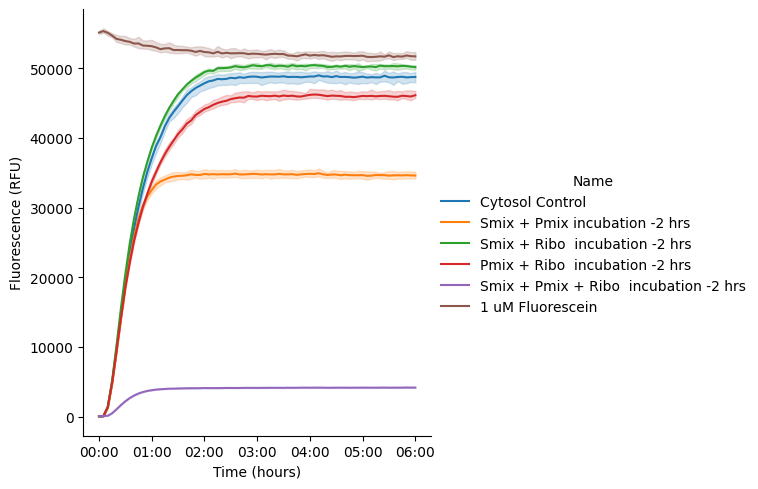

In [3]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics")

## Normalize Data

In [4]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

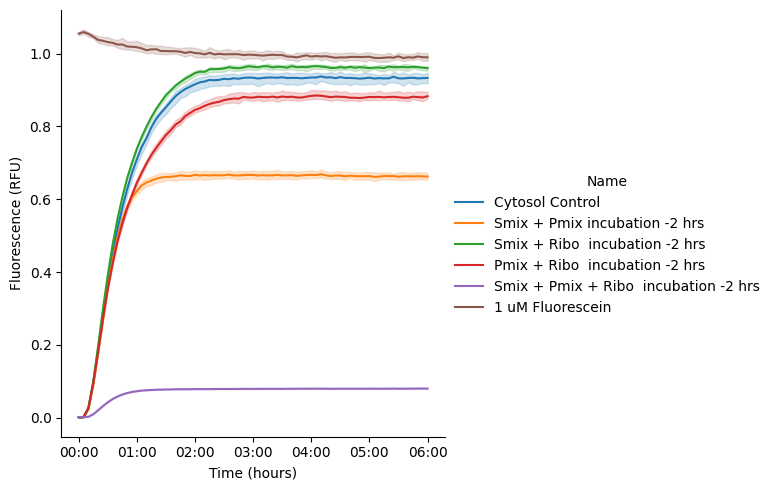

In [5]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics-normalized")

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [6]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well','Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                  \
                                                        Time data_normalized   
Well Name                                                                      
B2   Cytosol Control               0 days 00:35:10.164293646            0.48   
B4   Cytosol Control               0 days 00:35:17.905262989            0.47   
B6   Cytosol Control               0 days 00:34:56.880160611            0.48   
D2   Smix + Pmix incubation -2 hrs 0 days 00:28:48.184016998            0.34   
D4   Smix + Pmix incubation -2 hrs 0 days 00:28:40.446451776            0.33   

                                                              Lag  \
                                    Max                      Time   
Well Name                                                           
B2   Cytosol Control               0.93 0 days 00:04:04.495940317   
B4   Cytosol Control               0.90 0 days 00:03:58.856264697   
B6   Cytosol Control               0.94 0 days 00:04:18.088692067   
D2   Smix + Pmix incubation -2 hrs 1.12 0 days 00:10:29.738327595   
D4   Smix + Pmix incubation -2 hrs 1.08 0 days 00:10:18.335510450   

                                                                Steady State  \
                                   data_normalized                      Time   
Well Name                                                                      
B2   Cytosol Control                          0.04 0 days 01:20:56.837603562   
B4   Cytosol Control                          0.04 0 days 01:21:24.277818697   
B6   Cytosol Control                          0.04 0 days 01:20:03.984796982   
D2   Smix + Pmix incubation -2 hrs            0.06 0 days 00:55:45.337167721   
D4   Smix + Pmix incubation -2 hrs            0.06 0 days 00:55:42.995658136   

                                                    \
                                   data_normalized   
Well Name                                            
B2   Cytosol Control                          0.92   
B4   Cytosol Control                          0.89   
B6   Cytosol Control                          0.91   
D2   Smix + Pmix incubation -2 hrs            0.65   
D4   Smix + Pmix incubation -2 hrs            0.63   

                                                                                  Fit  \
                                                                               params   
Well Name                                                                               
B2   Cytosol Control                [0.9672715714373237, 3.859206803635551, 0.5861...   
B4   Cytosol Control                [0.9385017771594838, 3.8317255219733215, 0.588...   
B6   Cytosol Control                [0.95789197095622, 3.91561529709276, 0.5824667...   
D2   Smix + Pmix incubation -2 hrs  [0.6823136531985948, 6.554716428855764, 0.4800...   
D4   Smix + Pmix incubation -2 hrs  [0.66236194130267, 6.532917635681348, 0.477901...   

                                                        
                                    R^2 drift good_fit  
Well Name                                               
B2   Cytosol Control               0.99  0.01     True  
B4   Cytosol Control               0.99  0.01     True  
B6   Cytosol Control               0.99  0.01     True  
D2   Smix + Pmix incubation -2 hrs 1.00  0.00     True  
D4   Smix + Pmix incubation -2 hrs 1.00  0.00     True

## Visualize Fits on Individual Wells

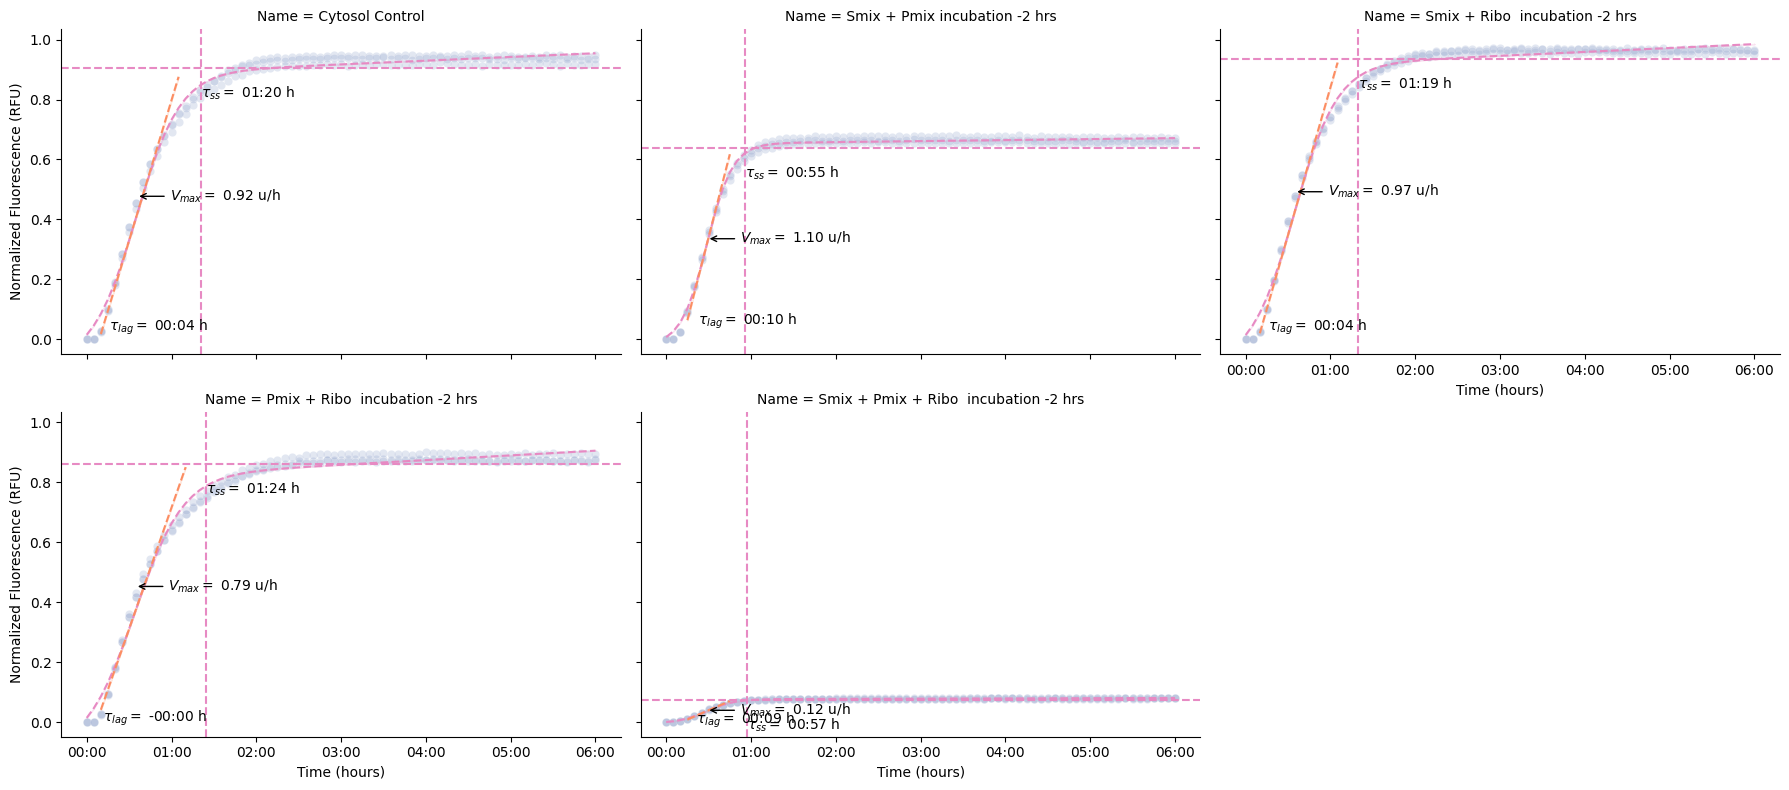

In [7]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics)

## Summary Plots

Calculating Kinetics


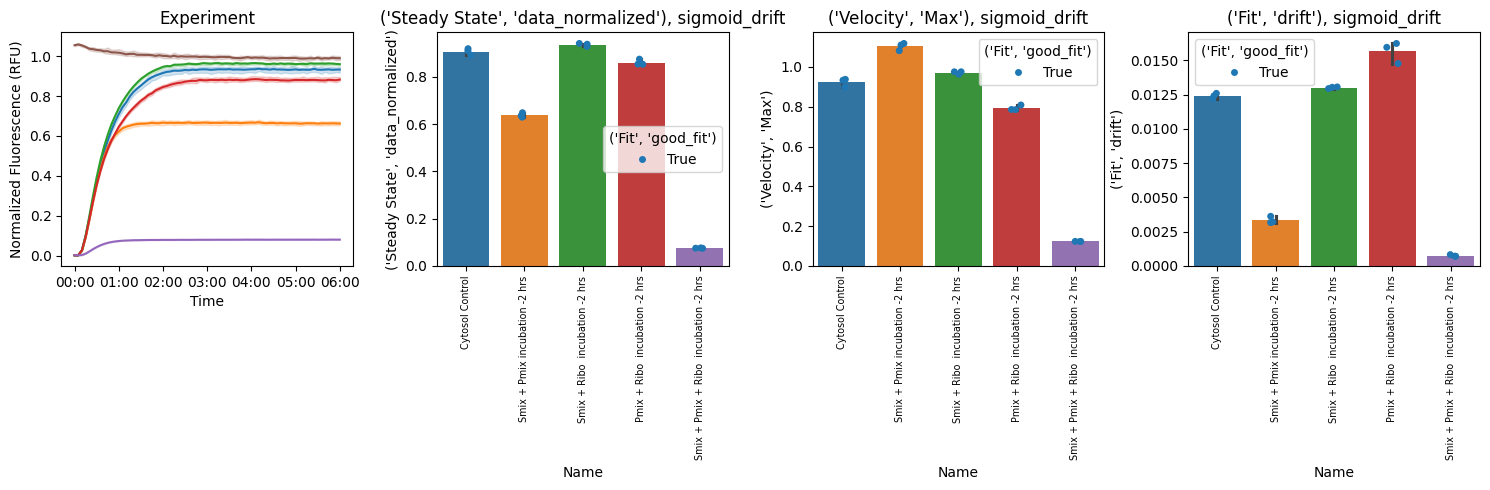

In [8]:
g = pr.plot_summary(data)
plt.savefig("summary")

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants